Notebook for results

In [1]:
#Import libraries

#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp
import json

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
install_path_local2 = "/home/andress/pylabs/SCICoNE_lab/build2/"
temporary_outpath = './'
adatas_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)
sci2 = scicone.SCICoNE(install_path_local2, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/
Using binaries at /home/andress/pylabs/SCICoNE_lab/build2/


In [2]:
gr_annotations_df = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

In [3]:
adata = anndata.read_h5ad('/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas/adata_leiden.h5ad') 

gr_annotations = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

df_annotations = gr_annotations.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]


df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])


In [4]:
#SORT ADATA OBJECT (already sorted)

# Merge Chromosome and End information into adata.var
# adata.var = adata.var.merge(gr_annotations_df[['ensembl_gene_id', 'Chromosome', 'End']], 
#                             on='ensembl_gene_id', how='left')

# print(adata.var.columns)

# adata.var['Chromosome'] = adata.var['Chromosome'].astype(str)  # Convert Chromosome to string

# # Sort adata.var by Chromosome and End
# sorted_var = adata.var.sort_values(by=['Chromosome', 'End'])

# # Reorder adata.X columns based on the sorted var index
# adata = adata[:, sorted_var.index]

In [5]:
chr_var_names = dict()
for chromosome in df_exp_annotations_sorted['Chromosome'].unique():
    chr_var_names[chromosome] = df_exp_annotations_sorted.query(f' Chromosome=="{chromosome}" ')\
                                .sort_values('Start')['ensembl_gene_id'].values

# Load the JSON file as a dictionary
json_file_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/chromosome_stops.json'
with open(json_file_path, 'r') as file:
    chromosome_stops = json.load(file)

#sort the dictionary by values
chromosome_stops = {k: v for k, v in sorted(chromosome_stops.items(), key=lambda item: item[1])}
chromosome_stops = {np.str_(k): np.int64(v) for k, v in chromosome_stops.items()}

# Use chromosome_stops directly without further processing
#add 0 and final position
chromosome_stops_list = [np.int64(0)] + sorted(list(chromosome_stops.values())) + [np.int64(adata.shape[1]-1)]

print(chromosome_stops_list)


[np.int64(0), np.int64(218), np.int64(2859), np.int64(3508), np.int64(4457), np.int64(5335), np.int64(6090), np.int64(6370), np.int64(7179), np.int64(8215), np.int64(8612), np.int64(9783), np.int64(10119), np.int64(11024), np.int64(11571), np.int64(12091), np.int64(12519), np.int64(13423), np.int64(14172), np.int64(15474), np.int64(15845), np.int64(16110), np.int64(16505), np.int64(16700), np.int64(17151), np.int64(17151)]


In [6]:
# import matplotlib.pyplot as plt
# file_list = ['adata_clusters_median', 'adata_clusters_mean', 'adata_clusters_sum', 'clusters_mean_transformed',
#              'clusters_sum_transformed', 'clusters_median_transformed']
# # Initialize a dictionary to store results
# breakpoints_data = {}

# for cluster_file in file_list:
#     breakpoints_data[cluster_file] = []
#     for window_size in range(200, 800, 100):
#         try:
#             adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
#             data = adata.X
#             # Run SCICoNE analysis
#             matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
#             bps = sci.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list)
#             breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
#             scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
#                                                 chr_stops_dict=chromosome_stops,
#                                                 cbar_title='Normalized\n  counts', vmax=2, cluster=False)
#             plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
#             plt.close()

#             #Learn and save the tree plot
            
#             inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
#             inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

#             tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
#             #Render the tree plot using graphviz's render method

#             inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
#             print(f"Tree plot saved to {tree_plot_filename}.png")

#         except Exception as e:
#             print(f"Error processing {cluster_file} with window size {window_size}: {e}")
#             continue

# # Plot the results
# for cluster_file, data_points in breakpoints_data.items():
#     if data_points:
#         window_sizes, breakpoints_counts = zip(*data_points)
#         plt.figure(figsize=(8, 6))
#         plt.plot(window_sizes, breakpoints_counts, marker='o', label=cluster_file)
#         plt.title(f'Breakpoints Detected vs Window Size for {cluster_file}')
#         plt.xlabel('Window Size')
#         plt.ylabel('Number of Breakpoints Detected')
#         plt.legend()
#         plt.grid(True)
#         plt.show()
#         #save plots
#         plt.savefig(f"{temporary_outpath}/breakpoints_plot_{cluster_file}.png", dpi=300, bbox_inches='tight')



In [ ]:
#Define a function to evaluate the similarity between two lists with breakpoint indices
def evaluate_similarity(bps1, bps2):
    """
    Evaluate the similarity between two lists of breakpoint indices.
    """
    # Convert lists to sets for easier comparison
    set1 = set(bps1)
    set2 = set(bps2)

    # Calculate Jaccard similarity
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    sim = (intersection / union) * 100 if union != 0 else 0

    return sim

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 748.089
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
Adding 218: 74808.9
2858, 2860
2857, 2861
2856, 2862
2855, 2863
2854, 2864
2853, 2865
2852, 2866
2851, 2867
2850, 2868
2849, 2869
2848, 2870
2847, 2871
2846, 2872
2845, 2873
2844, 2874
2843, 2875
2842, 2876
2841, 2877
2840, 2878
2839, 2879
2838, 2880
2837, 2881
2836, 2882
2835, 2883
Adding 2859: 74808.9
3507, 3509
3506, 3510
3505, 3511
3504

no breakpoints are found within the interval: (16649,16665)


Index of the maximum 9231 is added to all_max_ids.
Index of the maximum 9284 is added to all_max_ids.
Index of the maximum 9257 is added to all_max_ids.
Index of the maximum 9214 is added to all_max_ids.
Index of the maximum 9180 is added to all_max_ids.
Found 38 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ordered segmented region sizes to file...
Segmented region sizes are written to file


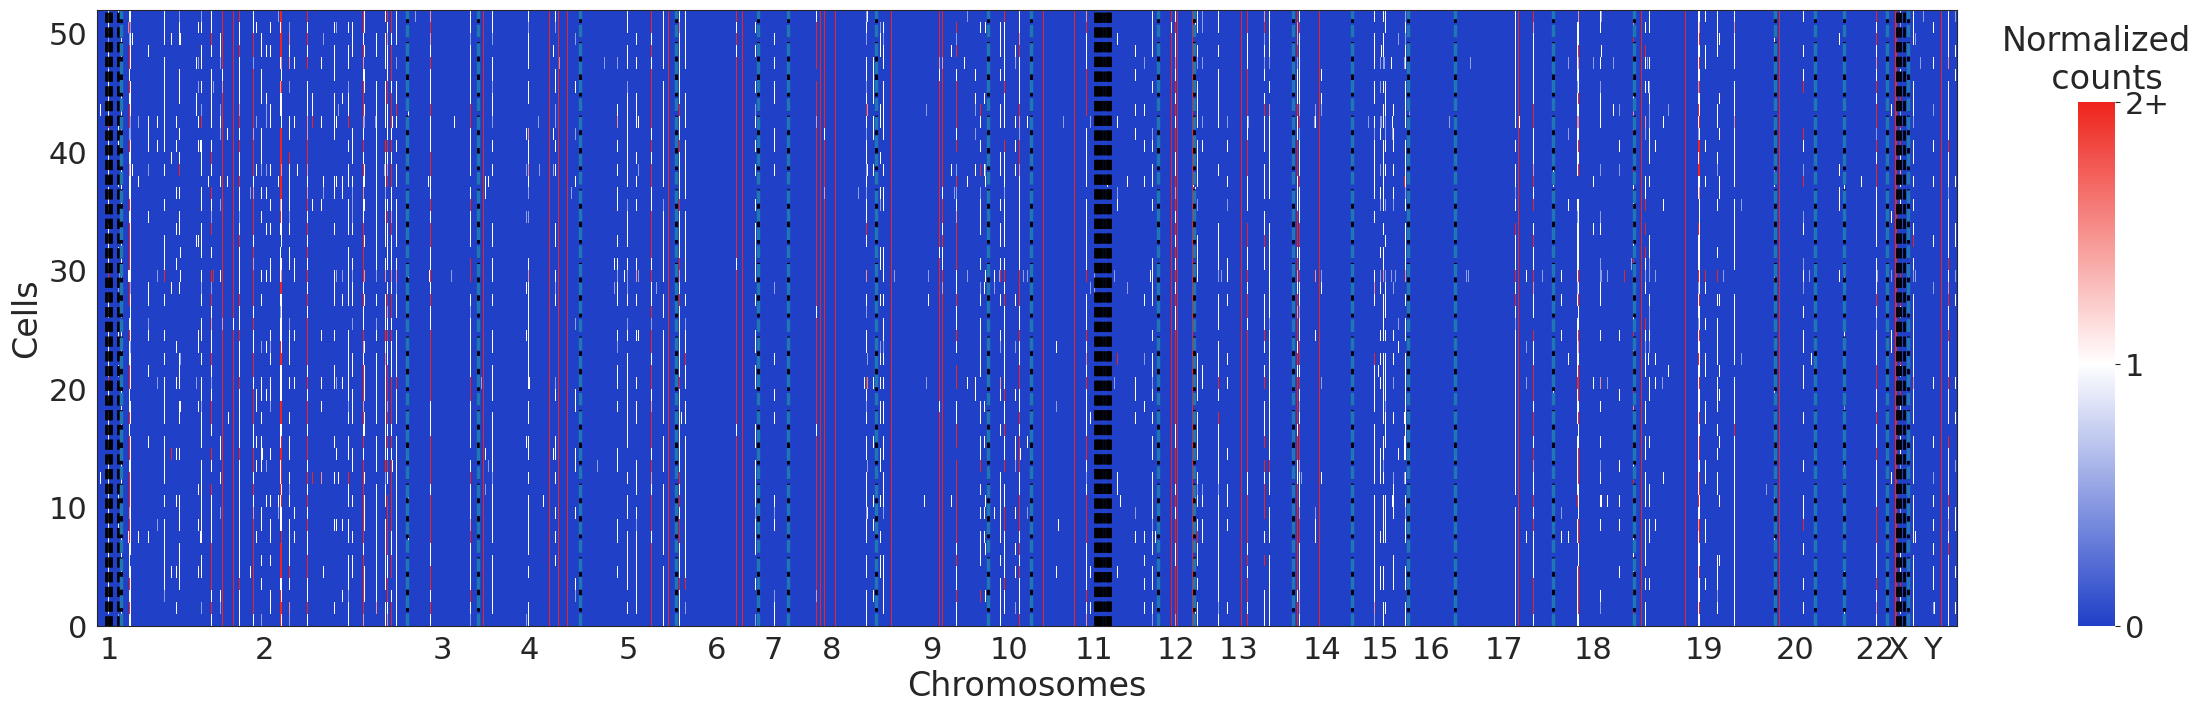

In [ ]:

cluster_file = 'adata_clusters_median'
window_size = 25

#for a in ['Average', 'Sigmoid', 'Gaussian']:
try:
    adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
    data = adata.X
    # Run SCICoNE analysis
    matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
    bps = sci2.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list, mode = "RNA", weight = "gaussian")
    #breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
    scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                        chr_stops_dict= chromosome_stops,
                                        cbar_title='Normalized\n  counts', vmax=2, cluster=False)
    plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
    plt.close()

    #Learn and save the tree plot
    
    # inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
    # inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

    # tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
    # #Render the tree plot using graphviz's render method

    # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
    # # print(f"Tree plot saved to {tree_plot_filename}.png")


except Exception as e:
    print(f"Error processing {cluster_file} with window size {window_size}: {e}")


In [2]:
len(bps['segmented_regions'])

bps['segmented_region_sizes']

NameError: name 'bps' is not defined

Condensing regions...
Done.
Learning cluster tree...
n_neighbours to be used: 5
Setting min_cluster_size to 1
Finding 5 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10083222389221191 seconds
Jaccard graph constructed in 0.0022068023681640625 seconds
Wrote graph to binary file in 0.0013804435729980469 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.611126
After 4 runs, maximum modularity is Q = 0.616053
Louvain completed 24 runs in 0.1389451026916504 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.5075123310089111 seconds
Found 5 clusters.
Cluster sizes: [14. 14. 12.  9.  3.]
Creating ./rep3_try0_PYSCICONETREETEMP_PYSCICONETEMP...Creating ./rep1_try0_PYSCICONETREETEMP_PYSCICONETEMP...Creating ./rep2_try0_PYSCICONETREETEMP_PYSCICONETEMP...Creating ./rep0_try0_PYSCICONETREETEMP_PYSCICONETEMP...



Created ./rep1_try0_PYSCICONETREETEMP_PYSCICONETEMP!Created ./rep3_try0_PYSCICON

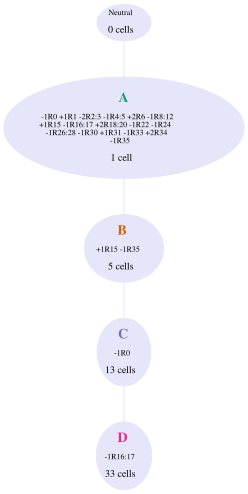

In [8]:

    
inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
inferred_tree.plot_tree(gene_labels=True, node_labels=True, tumor_type='breast', node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

#tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
#Render the tree plot using graphviz's render method

# inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
# # print(f"Tree plot saved to {tree_plot_filename}.png")

